## 1. Setup and Configuration

In [1]:
# =============================================================================
# SETUP AND CONFIGURATION
# =============================================================================

import os
import sys
import torch

# Import utilities from src modules
from src.utils.config import load_config
from src.utils.seed import set_seed
from src.utils.device import get_device

# Load and validate configuration
config = load_config('configs/default_config.yaml', validate=True)

# Set random seed for reproducibility
set_seed(config['seed'])

# Get device (GPU if available, else CPU)
device = get_device("auto")

print("\n" + "="*80)
print("CONFIGURATION LOADED")
print("="*80)
print(f"Experiment: {config['logging']['experiment_name']}")
print(f"Seed: {config['seed']}")
print(f"Device: {device}")
print("="*80)


✓ Configuration validation passed
Using device: cpu

CONFIGURATION LOADED
Experiment: oversampling_B_rnn
Seed: 42
Device: cpu


## 2. Data Loading

In [2]:
import pandas as pd
import numpy as np

# Load raw data
data_config = config['data']
X_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_file']))
y_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_labels_file']))
X_test = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['test_file']))

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Check class distribution
print("\nClass distribution:")
for label, count in y_train['label'].value_counts().sort_index().items():
    pct = count / len(y_train) * 100
    print(f"  {label}: {count:4d} samples ({pct:5.2f}%)")
print("="*80)


DATA LOADING
Training data shape: (105760, 40)
Training labels shape: (661, 2)
Test data shape: (211840, 40)

Class distribution:
  high_pain:   56 samples ( 8.47%)
  low_pain:   94 samples (14.22%)
  no_pain:  511 samples (77.31%)


## 3. Data Preprocessing

Apply all preprocessing steps defined in the configuration:
- Fix skewed features
- Drop constant/redundant features
- Combine highly correlated features
- Create prosthesis indicator
- Map labels to integers

In [3]:
from src.preprocessing.utils import preprocess_pirates_data

# Preprocess data according to config
X_train, y_train = preprocess_pirates_data(X_train, y_train, config, verbose=True)

# Save processed data
os.makedirs(config['data']['processed_dir'], exist_ok=True)
X_train.to_csv(os.path.join(config['data']['processed_dir'], 'X_train_processed.csv'), index=False)
y_train.to_csv(os.path.join(config['data']['processed_dir'], 'y_train_processed.csv'), index=False)

print(f"\n✓ Processed data saved to {config['data']['processed_dir']}")


PREPROCESSING PIRATES PAIN DATA
Detected 13 skewed features (|skew| > 5.0):
  joint_13: skew=36.26
  joint_14: skew=108.27
  joint_15: skew=33.36
  joint_16: skew=57.07
  joint_17: skew=33.52
  joint_18: skew=63.59
  joint_19: skew=88.02
  joint_20: skew=79.39
  joint_21: skew=256.08
  joint_22: skew=226.58
  joint_23: skew=204.95
  joint_24: skew=37.84
  joint_25: skew=250.58

After transformation:
  joint_13: skew=6.76
  joint_14: skew=6.80
  joint_15: skew=7.13
  joint_16: skew=7.28
  joint_17: skew=7.40
  joint_18: skew=7.28
  joint_19: skew=6.63
  joint_20: skew=6.92
  joint_21: skew=6.03
  joint_22: skew=6.21
  joint_23: skew=6.40
  joint_24: skew=6.55
  joint_25: skew=6.09
Dropped feature: joint_30
Combined joint_00 and joint_02 → joint_00_02
Combined joint_01 and joint_03 → joint_01_03
Combined joint_10 and joint_11 → joint_10_11
Created has_prosthesis feature from body part indicators
Mapped labels: {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}

Final shape: (105760, 34)

✓ Pr

## 4. Train-Validation Split

In [4]:
from src.preprocessing.utils import split_train_val

# Split into train and validation sets with stratification
X_train_split, X_val_split, y_train_split, y_val_split = split_train_val(
    X_train,
    y_train,
    val_size=config['split']['val_size'],
    stratify=config['split']['stratify'],
    seed=config['seed']
)


Stratified split by user labels:
  Train users: 561 (85.0%)
  Val users:   100 (15.0%)

Train: 89760 samples from 561 users
  Class 0: 77.36%
  Class 1: 14.26%
  Class 2:  8.38%

Val:   16000 samples from 100 users
  Class 0: 77.00%
  Class 1: 14.00%
  Class 2:  9.00%

Train: 89760 samples from 561 users
  Class 0: 77.36%
  Class 1: 14.26%
  Class 2:  8.38%

Val:   16000 samples from 100 users
  Class 0: 77.00%
  Class 1: 14.00%
  Class 2:  9.00%


## 5. Feature Normalization

In [5]:
from src.preprocessing.utils import normalize_features

# Get feature columns to normalize (exclude metadata and label columns)
exclude_cols = ['sample_index', 'time', 'label']
# Also exclude categorical indicators if they exist
if 'has_prosthesis' in X_train_split.columns:
    exclude_cols.append('has_prosthesis')

feature_columns = [col for col in X_train_split.columns if col not in exclude_cols]

print(f"Normalizing {len(feature_columns)} features using min-max scaling")
print(f"Features: {feature_columns[:5]}... (showing first 5)")

# Normalize features (fit on train, apply to both train and val)
X_train_norm, X_val_norm = normalize_features(X_train_split, X_val_split, feature_columns)

print(f"\n✓ Features normalized")
print(f"  Train range: [{X_train_norm[feature_columns].min().min():.4f}, {X_train_norm[feature_columns].max().max():.4f}]")
print(f"  Val range: [{X_val_norm[feature_columns].min().min():.4f}, {X_val_norm[feature_columns].max().max():.4f}]")


Normalizing 31 features using min-max scaling
Features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_04']... (showing first 5)

✓ Features normalized
  Train range: [0.0000, 1.0000]
  Val range: [0.0000, 1.0000]


## 6. Sequence Building

Create sliding window sequences for time series classification.

In [6]:
from src.preprocessing.utils import build_sequences

# Merge features with labels for sequence building
df_train = pd.merge(X_train_norm, y_train_split, on='sample_index', how='inner')
df_val = pd.merge(X_val_norm, y_val_split, on='sample_index', how='inner')

# Convert to float32 for memory efficiency
df_train[feature_columns] = df_train[feature_columns].astype(np.float32)
df_val[feature_columns] = df_val[feature_columns].astype(np.float32)

# Build sequences with sliding windows
print("="*80)
print("SEQUENCE BUILDING")
print("="*80)
print(f"Window size: {config['sequences']['window_size']}")
print(f"Stride: {config['sequences']['stride']}")
print()

X_train_seq, y_train_seq = build_sequences(
    df_train,
    window=config['sequences']['window_size'],
    stride=config['sequences']['stride'],
    feature_columns=feature_columns
)

X_val_seq, y_val_seq = build_sequences(
    df_val,
    window=config['sequences']['window_size'],
    stride=config['sequences']['stride'],
    feature_columns=feature_columns
)

print(f"✓ Sequences built successfully")
print(f"  Training sequences: {X_train_seq.shape} (samples, timesteps, features)")
print(f"  Validation sequences: {X_val_seq.shape}")
print(f"  Number of features: {X_train_seq.shape[2]}")
print(f"  Number of classes: {len(np.unique(y_train_seq))}")

# Update config with inferred values
config['model']['input_size'] = X_train_seq.shape[2]
config['model']['num_classes'] = len(np.unique(y_train_seq))
print("="*80)


SEQUENCE BUILDING
Window size: 160
Stride: 160

✓ Sequences built successfully
  Training sequences: (561, 160, 31) (samples, timesteps, features)
  Validation sequences: (100, 160, 31)
  Number of features: 31
  Number of classes: 3
✓ Sequences built successfully
  Training sequences: (561, 160, 31) (samples, timesteps, features)
  Validation sequences: (100, 160, 31)
  Number of features: 31
  Number of classes: 3


In [7]:
from src.preprocessing.utils import oversample_minority_classes

print("="*80)
print("DATA AUGMENTATION & OVERSAMPLING")
print("="*80)

# Show original class distribution
print("\n📊 Class Distribution BEFORE Oversampling:")
unique_train, counts_train = np.unique(y_train_seq, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"  Class {cls}: {count:5d} samples ({count/len(y_train_seq)*100:5.2f}%)")

# Apply oversampling if enabled in config
if config['augmentation']['enabled'] and config['augmentation']['oversample']:
    # Prepare augmentation parameters
    augment_params = {
        'noise_level': config['augmentation']['noise_level'],
        'scale_range': tuple(config['augmentation']['scale_range']),
        'shift_range': config['augmentation']['shift_range'],
        'apply_noise': config['augmentation']['apply_noise'],
        'apply_scaling': config['augmentation']['apply_scaling'],
        'apply_shift': config['augmentation']['apply_shift']
    }
    
    print(f"\n🔧 Augmentation Settings:")
    print(f"  Target Distribution: {config['augmentation']['target_distribution']}")
    print(f"  Augment Duplicates: {config['augmentation']['augment_duplicates']}")
    print(f"  Noise Level: {config['augmentation']['noise_level']}")
    print(f"  Scale Range: {config['augmentation']['scale_range']}")
    print(f"  Shift Range: ±{config['augmentation']['shift_range']} timesteps")
    print()
    
    # Apply oversampling with augmentation
    X_train_seq, y_train_seq = oversample_minority_classes(
        X_train_seq,
        y_train_seq,
        target_distribution=config['augmentation']['target_distribution'],
        augment=config['augmentation']['augment_duplicates'],
        augment_params=augment_params,
        seed=config['seed']
    )
    
    print("\n✅ Augmentation complete!")
else:
    print("\n⚠️  Augmentation disabled in config")
    print("   Set augmentation.enabled=True and augmentation.oversample=True to enable")

# Update config with final values
config['model']['input_size'] = X_train_seq.shape[2]
config['model']['num_classes'] = len(np.unique(y_train_seq))
print("="*80)


DATA AUGMENTATION & OVERSAMPLING

📊 Class Distribution BEFORE Oversampling:
  Class 0:   434 samples (77.36%)
  Class 1:    80 samples (14.26%)
  Class 2:    47 samples ( 8.38%)

🔧 Augmentation Settings:
  Target Distribution: balanced
  Augment Duplicates: True
  Noise Level: 0.01
  Scale Range: [0.95, 1.05]
  Shift Range: ±5 timesteps

Oversampling to balanced distribution:
Target count per class: 187
  Class 0: 434 (no oversampling needed)
  Class 1: 80 → 187 (+107 samples)
  Class 2: 47 → 187 (+140 samples)

Final dataset size: 808 samples
Final class distribution:
  Class 0:   434 samples (53.71%)
  Class 1:   187 samples (23.14%)
  Class 2:   187 samples (23.14%)

✅ Augmentation complete!


## 7. Create DataLoaders

In [8]:
from src.preprocessing.dataloaders import create_dataloaders
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for handling class imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("="*80)
print("CLASS WEIGHTS (for loss function)")
print("="*80)
for i, (cls, cnt) in enumerate(zip(*np.unique(y_train_seq, return_counts=True))):
    print(f"  Class {cls}: {cnt:5d} samples ({cnt/len(y_train_seq)*100:5.2f}%) → weight: {class_weights[i]:.4f}")
print("="*80)

# Create dummy test data (we'll use validation for now since test has no labels)
X_test_seq, y_test_seq = X_val_seq, y_val_seq

# Auto-detect pin_memory based on device (only useful for CUDA)
pin_memory = config['dataloader']['pin_memory'] and (device.type == 'cuda')
if config['dataloader']['pin_memory'] and device.type != 'cuda':
    print(f"\n⚠️  pin_memory disabled (only useful with GPU/CUDA)")

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    X_test_seq, y_test_seq,
    batch_size=config['training']['batch_size'],
    num_workers=config['dataloader']['num_workers'],
    shuffle=config['dataloader']['shuffle_train'],
    drop_last=config['dataloader']['drop_last'],
    pin_memory=pin_memory  # Auto-detected based on device
)

print(f"\n✓ DataLoaders created")
print(f"  Train batches: {len(train_loader)} (total samples: {len(train_loader.dataset)})")
print(f"  Val batches: {len(val_loader)} (total samples: {len(val_loader.dataset)})")
print(f"  Test batches: {len(test_loader)} (total samples: {len(test_loader.dataset)})")
print(f"  pin_memory: {pin_memory}")

# Check a batch
for xb, yb in train_loader:
    print(f"\nSample batch:")
    print(f"  Input shape: {xb.shape} (batch_size, timesteps, features)")
    print(f"  Labels shape: {yb.shape}")
    break


CLASS WEIGHTS (for loss function)
  Class 0:   434 samples (53.71%) → weight: 0.6206
  Class 1:   187 samples (23.14%) → weight: 1.4403
  Class 2:   187 samples (23.14%) → weight: 1.4403

✓ DataLoaders created
  Train batches: 13 (total samples: 808)
  Val batches: 2 (total samples: 100)
  Test batches: 2 (total samples: 100)
  pin_memory: False

Sample batch:
  Input shape: torch.Size([64, 160, 31]) (batch_size, timesteps, features)
  Labels shape: torch.Size([64])


## 8. Model Creation

Create the model from configuration.

In [9]:
import torch.nn as nn
from src.models.rnn_models import RecurrentNet

print("="*80)
print("MODEL CREATION")
print("="*80)

# Create model from config
model = RecurrentNet(
    input_size=config['model']['input_size'],
    hidden_size=config['model']['hidden_size'],
    num_layers=config['model']['num_layers'],
    num_classes=config['model']['num_classes'],
    rnn_type=config['model']['rnn_type'],
    bidirectional=config['model']['bidirectional'],
    dropout_rate=config['model']['dropout_rate'],
    task=config['model']['task']
).to(device)

print(f"✓ Model created: {config['model']['rnn_type']}")
print(f"  Architecture: {config['model']['rnn_type']} ")
print(f"  Hidden size: {config['model']['hidden_size']}")
print(f"  Num layers: {config['model']['num_layers']}")
print(f"  Bidirectional: {config['model']['bidirectional']}")
print(f"  Dropout: {config['model']['dropout_rate']}")
print(f"\n  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*80)


MODEL CREATION
✓ Model created: RNN
  Architecture: RNN 
  Hidden size: 128
  Num layers: 2
  Bidirectional: True
  Dropout: 0.3

  Total parameters: 140,803
  Trainable parameters: 140,803


## 9. Training Setup

⚠️ **Important Notes:**
- If you re-run this cell, the previous TensorBoard writer will be closed to prevent duplicate logs
- The scheduler is managed internally by the Trainer class
- Mixed precision (AMP) is only enabled when using GPU (CUDA)

In [10]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

print("="*80)
print("TRAINING SETUP")
print("="*80)

# Create class-weighted loss function for handling imbalanced data
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Create optimizer with L2 regularization (weight decay)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['training']['learning_rate'],
    weight_decay=config['training']['l2_lambda']
)

# NOTE: Scheduler is created inside Trainer class, not here
# This prevents duplicate scheduler creation

# Create TensorBoard writer
# Close any existing writer to prevent duplicate logs
try:
    if 'writer' in locals() and writer is not None:
        writer.close()
        print("  Closed previous TensorBoard writer")
except:
    pass

os.makedirs(config['logging']['tensorboard_dir'], exist_ok=True)
experiment_name = f"{config['logging']['experiment_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(os.path.join(config['logging']['tensorboard_dir'], experiment_name))

print(f"✓ Training setup complete")
print(f"  Optimizer: AdamW (lr={config['training']['learning_rate']}, weight_decay={config['training']['l2_lambda']})")
print(f"  Loss function: CrossEntropyLoss (class-weighted)")
print(f"  Scheduler: {'Enabled' if config['training']['scheduler']['enabled'] else 'Disabled'} (managed by Trainer)")
print(f"  TensorBoard: {experiment_name}")
print("="*80)


TRAINING SETUP
✓ Training setup complete
  Optimizer: AdamW (lr=0.001, weight_decay=0.001)
  Loss function: CrossEntropyLoss (class-weighted)
  Scheduler: Enabled (managed by Trainer)
  TensorBoard: oversampling_B_rnn_20251111_120751
✓ Training setup complete
  Optimizer: AdamW (lr=0.001, weight_decay=0.001)
  Loss function: CrossEntropyLoss (class-weighted)
  Scheduler: Enabled (managed by Trainer)
  TensorBoard: oversampling_B_rnn_20251111_120751


## 10. Model Training

Train the model using the Trainer class.

⚠️ **Note:** If you need to re-run training, it's recommended to restart the kernel and run all cells from the beginning to avoid state issues.

In [11]:
from src.training.trainer import Trainer

# Create trainer with all components
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    config=config,
    writer=writer,
    experiment_name=experiment_name,
    task=config['model']['task']
)

# Train model
print("\n" + "="*80)
print("TRAINING")
print("="*80)
print(f"Epochs: {config['training']['epochs']}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Early stopping patience: {config['training']['patience']}")
print(f"Evaluation metric: {config['training']['evaluation_metric']}")
print("="*80 + "\n")

history = trainer.fit()

print("\n" + "="*80)
print("✅ TRAINING COMPLETE")
print("="*80)



TRAINING
Epochs: 500
Batch size: 64
Early stopping patience: 50
Evaluation metric: val_f1

Training for 500 epochs...
Task: CLASSIFICATION | Primary metric: F1
Device: cpu | Mixed Precision: Disabled (CPU only)
Logging to TensorBoard: True
Models will be saved to: ./models
--------------------------------------------------------------------------------
Epoch   1/500 | Train: Loss=1.4298, F1=0.4121 | Val: Loss=0.9218, F1=0.6990
✓ New best F1: 0.6990
Epoch   1/500 | Train: Loss=1.4298, F1=0.4121 | Val: Loss=0.9218, F1=0.6990
✓ New best F1: 0.6990
✓ New best F1: 0.7516
✓ New best F1: 0.7516
✓ New best F1: 0.7654
✓ New best F1: 0.7654
Epoch  10/500 | Train: Loss=0.9452, F1=0.7117 | Val: Loss=0.8709, F1=0.6635
Epoch  10/500 | Train: Loss=0.9452, F1=0.7117 | Val: Loss=0.8709, F1=0.6635
✓ New best F1: 0.7669
✓ New best F1: 0.7669
✓ New best F1: 0.7730
✓ New best F1: 0.7730
✓ New best F1: 0.7792
✓ New best F1: 0.7792
✓ New best F1: 0.8234
✓ New best F1: 0.8234
Epoch  20/500 | Train: Loss=0.66

## 11. Training Visualization

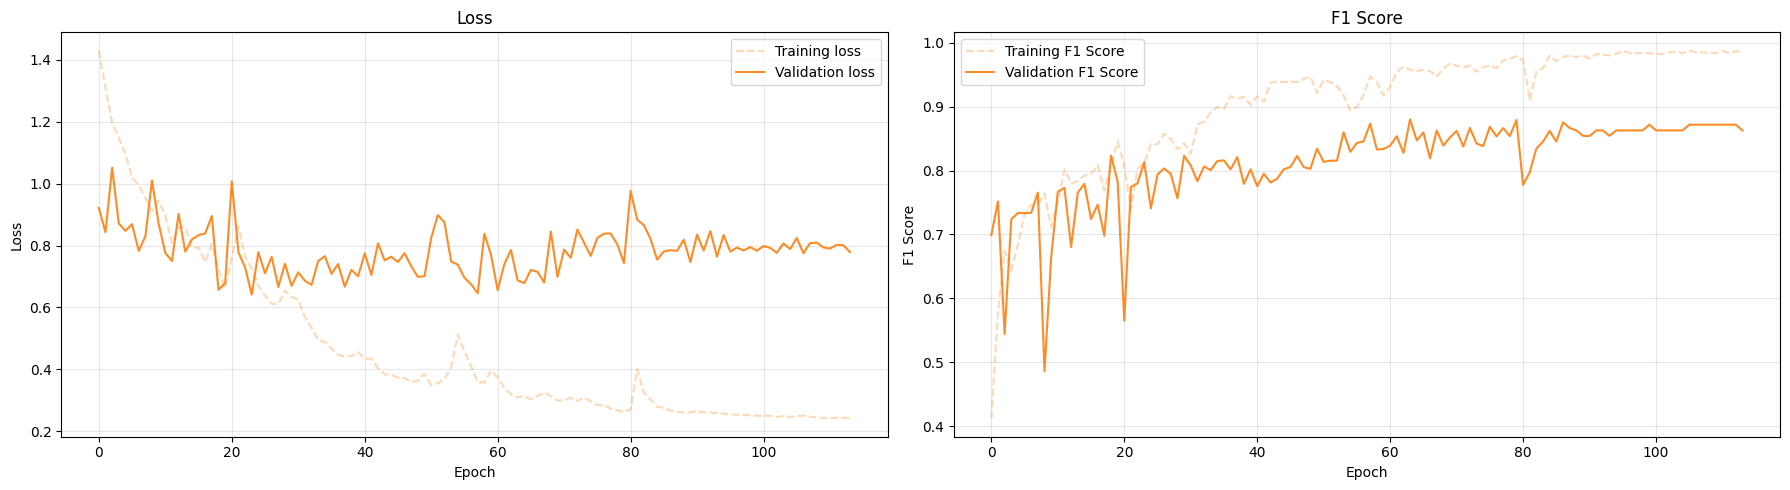

In [12]:
from src.training.metrics import plot_training_history

# Plot training history
plot_training_history(
    history,
    task=config['model']['task'],
    save_path=None
)

## 12. Model Evaluation


MODEL EVALUATION

Validation Metrics:
Accuracy:  0.8700
Precision: 0.8592
Recall:    0.8700
F1 Score:  0.8628


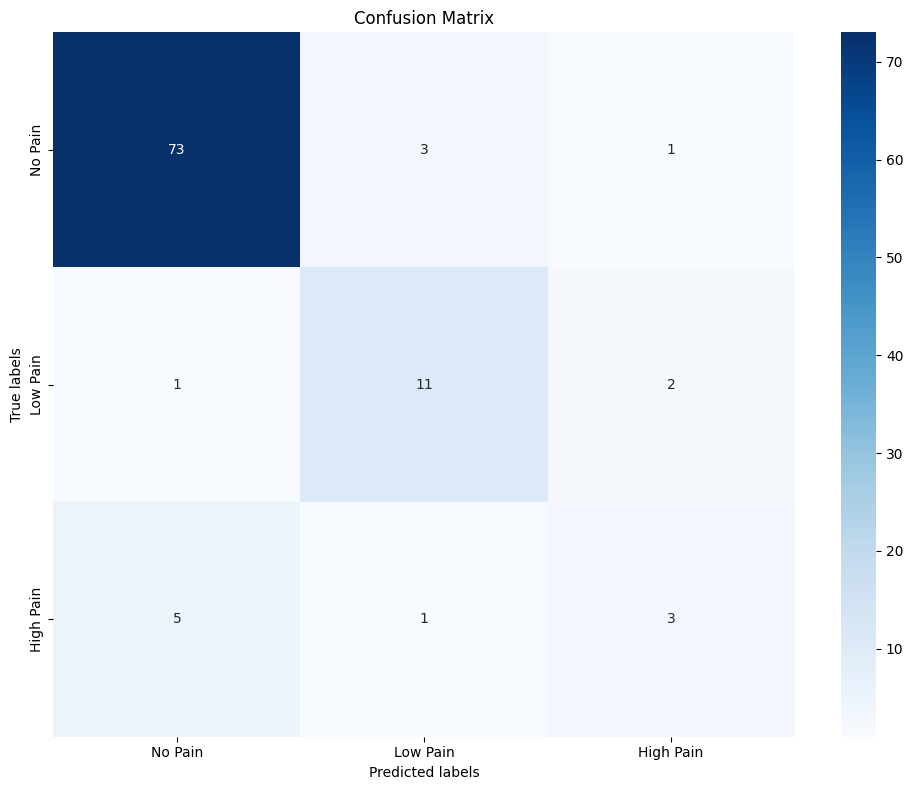

In [13]:
from src.evaluation.evaluate import evaluate_and_report

# Define class names for better visualization
class_names = ['No Pain', 'Low Pain', 'High Pain']

print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Evaluate on validation set
val_metrics = evaluate_and_report(
    model=model,
    data_loader=val_loader,
    device=device,
    dataset_name="Validation",
    task=config['model']['task'],
    class_names=class_names,
    plot_cm=True
)

print("="*80)


## 12.a. Cross-Validation (Optional)

Perform K-fold cross-validation if enabled in config.

In [14]:
if config['cross_validation']['enabled']:
    from src.training.cross_validation import k_fold_cross_validation, plot_cv_results
    from src.models.rnn_models import RecurrentNet
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION")
    print("="*80)
    print(f"K-folds: {config['cross_validation']['k_folds']}")
    print(f"Using entire training set (before train/val split)")
    print()
    
    # Prepare base model parameters
    base_model_params = {
        'input_size': config['model']['input_size'],
        'hidden_size': config['model']['hidden_size'],
        'num_layers': config['model']['num_layers'],
        'num_classes': config['model']['num_classes'],
        'rnn_type': config['model']['rnn_type'],
        'bidirectional': config['model']['bidirectional'],
        'dropout_rate': config['model']['dropout_rate'],
        'task': config['model']['task']
    }
    
    # Prepare base trainer parameters
    base_trainer_params = {
        'epochs': config['training']['epochs'],
        'batch_size': config['training']['batch_size'],
        'learning_rate': config['training']['learning_rate'],
        'weight_decay': config['training']['l2_lambda'],
        'patience': config['training']['patience'],
        'device': device,
        'optimizer': 'AdamW',
        'verbose': config['training']['verbose']
    }
    
    # Run K-fold cross-validation
    fold_losses, fold_metrics, best_scores = k_fold_cross_validation(
        X=X_train_seq,
        y=y_train_seq,
        model_class=RecurrentNet,
        base_model_params=base_model_params,
        base_trainer_params=base_trainer_params,
        k=config['cross_validation']['k_folds'],
        seed=config['seed'],
        use_class_weights=True,
        verbose=True
    )
    
    print("\n" + "="*80)
    print("📊 CROSS-VALIDATION SUMMARY")
    print("="*80)
    print(f"Mean F1: {best_scores['mean']:.4f} ± {best_scores['std']:.4f}")
    print(f"Min F1:  {min([best_scores[f'fold_{i}'] for i in range(config['cross_validation']['k_folds'])]):.4f}")
    print(f"Max F1:  {max([best_scores[f'fold_{i}'] for i in range(config['cross_validation']['k_folds'])]):.4f}")
    print("="*80)
    
    # Visualize results
    plot_cv_results(fold_metrics, k=config['cross_validation']['k_folds'])
else:
    print("\n⚠️  Cross-validation disabled in config")
    print("   Set cross_validation.enabled=True to run K-fold cross-validation")



CROSS-VALIDATION
K-folds: 5
Using entire training set (before train/val split)


K-Fold Cross-Validation (k=5)
Total samples: 808
Classes: [0 1 2]
Class distribution: [434 187 187]

Fold 1/5
Train: 646 samples | Val: 162 samples
Train class dist: [347 150 149]
Val class dist:   [87 37 38]
Class weights: [0.62055716 1.43555556 1.44519016]
Training for 500 epochs...
Task: CLASSIFICATION | Primary metric: F1
Device: cpu | Mixed Precision: Disabled (CPU only)
Logging to TensorBoard: False
Models will be saved to: ./models/cv/fold_0
--------------------------------------------------------------------------------
Epoch   1/500 | Train: Loss=1.1065, F1=0.4233 | Val: Loss=1.0539, F1=0.2319
✓ New best F1: 0.2319
Epoch   1/500 | Train: Loss=1.1065, F1=0.4233 | Val: Loss=1.0539, F1=0.2319
✓ New best F1: 0.2319
✓ New best F1: 0.5793
✓ New best F1: 0.5793
✓ New best F1: 0.6693
✓ New best F1: 0.6693
✓ New best F1: 0.6927
✓ New best F1: 0.6927
✓ New best F1: 0.6992
✓ New best F1: 0.6992
Epoch  10/50

KeyboardInterrupt: 

## 12.b. Hyperparameter Tuning (Optional)

Perform grid search over hyperparameters if enabled in config.

In [ ]:
if config['hyperparameter_tuning']['enabled']:
    from src.training.cross_validation import grid_search_hyperparameters, plot_grid_search_results
    from src.models.rnn_models import RecurrentNet
    
    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING")
    print("="*80)
    print("⚠️  WARNING: This is very time-consuming!")
    print("\nParameter Grid:")
    for param, values in config['hyperparameter_tuning']['param_grid'].items():
        print(f"  {param}: {values}")
    
    # Calculate total combinations
    param_grid = config['hyperparameter_tuning']['param_grid']
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    
    print(f"\nTotal combinations: {total_combinations}")
    print(f"Total training runs: {total_combinations * 5} (with 5-fold CV)")
    print()
    
    # Ask for confirmation
    proceed = input("Proceed with hyperparameter tuning? (yes/no): ").lower().strip()
    
    if proceed == 'yes':
        # Prepare base model parameters
        base_model_params = {
            'input_size': config['model']['input_size'],
            'num_classes': config['model']['num_classes'],
            'rnn_type': config['model']['rnn_type'],
            'bidirectional': config['model']['bidirectional'],
            'task': config['model']['task']
        }
        
        # Prepare base trainer parameters (add save_dir to save in models/tuning)
        base_trainer_params = {
            'epochs': config['training']['epochs'],
            'batch_size': config['training']['batch_size'],
            'weight_decay': config['training']['l2_lambda'],
            'patience': config['training']['patience'],
            'device': device,
            'optimizer': config['training']['optimizer'],
            'verbose': 10,
            'save_dir': config['logging']['save_dir']  # Save tuning models to configured directory
        }
        
        # Run grid search with cross-validation
        all_results, best_params, best_score = grid_search_hyperparameters(
            X=X_train_seq,
            y=y_train_seq,
            model_class=RecurrentNet,
            param_grid=param_grid,
            base_model_params=base_model_params,
            base_trainer_params=base_trainer_params,
            cv_k=5,
            cv_seed=config['seed'],
            use_class_weights=True,
            verbose=True
        )
        
        print("\n" + "="*80)
        print("🏆 HYPERPARAMETER TUNING RESULTS")
        print("="*80)
        print(f"Best Mean F1 Score: {best_score:.4f}")
        print("\nBest Parameters:")
        for param, value in best_params.items():
            print(f"  {param}: {value}")
        print("="*80)
        
        # Visualize results
        plot_grid_search_results(all_results, top_n=min(10, len(all_results)))
        
        print("\n💡 To use these parameters, update your config file with the best values above")
    else:
        print("❌ Hyperparameter tuning cancelled")
else:
    print("\n⚠️  Hyperparameter tuning disabled in config")
    print("   Set hyperparameter_tuning.enabled=True to run grid search")
    print("   WARNING: This is very time-consuming!")



HYPERPARAMETER TUNING
⚠️  WARNING: This is very time-consuming!

Parameter Grid:
  hidden_size: [64, 128]
  num_layers: [1, 2]
  learning_rate: [0.001, 0.01]
  dropout_rate: [0.1, 0.2]

Total combinations: 16
Total training runs: 80 (with 5-fold CV)


Grid Search Hyperparameter Tuning
Total configurations: 16
CV folds per config: 5
Total training runs: 80


Configuration 1/16
  hidden_size: 64
  num_layers: 1
  learning_rate: 0.001
  dropout_rate: 0.1
Training for 500 epochs...
Task: CLASSIFICATION | Primary metric: F1
Device: cpu | Mixed Precision: Disabled (CPU only)
Logging to TensorBoard: False
Models will be saved to: ./models/fold_0
--------------------------------------------------------------------------------

Grid Search Hyperparameter Tuning
Total configurations: 16
CV folds per config: 5
Total training runs: 80


Configuration 1/16
  hidden_size: 64
  num_layers: 1
  learning_rate: 0.001
  dropout_rate: 0.1
Training for 500 epochs...
Task: CLASSIFICATION | Primary metric: 

## 13. Save Final Results

In [ ]:
import json

print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Create save directory
os.makedirs(config['logging']['save_dir'], exist_ok=True)

# Save final results
results = {
    'experiment_name': experiment_name,
    'config': config,
    'val_metrics': val_metrics,
    'model_architecture': str(model),
    'total_parameters': sum(p.numel() for p in model.parameters())
}

results_path = os.path.join(config['logging']['save_dir'], f'{experiment_name}_results.json')
with open(results_path, 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    json_results = {}
    for key, value in results.items():
        if key == 'val_metrics':
            json_results[key] = {k: float(v) if isinstance(v, np.number) else v for k, v in value.items()}
        elif key == 'config':
            json_results[key] = value
        else:
            json_results[key] = value
    json.dump(json_results, f, indent=2)

print(f"✓ Results saved to: {results_path}")

# Close TensorBoard writer
writer.close()
print(f"✓ TensorBoard logs saved")

print("\n" + "="*80)
print("✅ ALL DONE!")
print("="*80)
print(f"\nTo view TensorBoard logs, run:")
print(f"  tensorboard --logdir {config['logging']['tensorboard_dir']}")
print("="*80)



SAVING RESULTS
✓ Results saved to: ./models/pirates_pain_classification_20251110_112952_results.json
✓ TensorBoard logs saved

✅ ALL DONE!

To view TensorBoard logs, run:
  tensorboard --logdir ./tensorboard
